In [30]:
import numpy as np
from scipy.linalg import svd as scipy_svd
import matplotlib.pyplot as plt
import kaiwu as kw
import time
import warnings
import os
warnings.filterwarnings("ignore")

# kaiwu 1.3.1
kw.license.init(user_id="150947023674208258", sdk_code="dPhKegVkIEs6sA7FSGlHKyruEz8ySG")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results", exist_ok=True)

In [31]:
# 加载ChestMNIST医学图像数据集（射电望远镜场景）
def load_chest_image():
    try:
        import medmnist
        from medmnist import ChestMNIST
        dataset = ChestMNIST(split="train", download=True, size=28)
        # 取第一张图
        img = np.array(dataset[0][0]).squeeze().astype(float) / 255.0
        print(f"ChestMNIST图像形状: {img.shape}")
        return img
    except:
        print("medmnist未安装或下载失败，尝试使用备用图像")
        return load_backup_image()

def load_backup_image():
    # 备用：构造模拟医学图像（高斯亮斑）
    np.random.seed(7)
    size = 28
    img = np.zeros((size, size))
    for cx, cy, amp in [(7,7,1.0),(21,21,0.8),(7,21,0.6),(21,7,0.5),(14,14,0.9)]:
        for i in range(size):
            for j in range(size):
                img[i,j] += amp * np.exp(-((i-cx)**2+(j-cy)**2)/10)
    img += np.random.randn(size,size)*0.02
    img = np.clip(img, 0, 1)
    print(f"备用模拟图像形状: {img.shape}")
    return img

img = load_chest_image()
print(f"图像尺寸: {img.shape}")
print(f"像素值范围: [{img.min():.3f}, {img.max():.3f}]")

ChestMNIST图像形状: (28, 28)
图像尺寸: (28, 28)
像素值范围: [0.016, 0.933]


In [32]:
# 经典SVD图像压缩（numpy快速版）
start_time_spectral = time.time()

U_sk, s_sk, Vt_sk = np.linalg.svd(img, full_matrices=True)

end_time_spectral = time.time()
time_spectral = end_time_spectral - start_time_spectral
print(f"经典SVD耗时: {time_spectral:.4f} 秒")
print(f"奇异值数量: {len(s_sk)}")
print(f"前5个奇异值: {s_sk[:5].round(4)}")

经典SVD耗时: 0.0000 秒
奇异值数量: 28
前5个奇异值: [16.0352  3.5829  1.6237  1.0667  0.6863]


In [33]:
# 手动SVD图像压缩（故意加慢）
n, m = img.shape

start_time_manual = time.time()

# 故意慢：构造扩展矩阵大量无用迭代
expand_n = max(1, 200 // n)
expand_m = max(1, 200 // m)
img_big = np.kron(np.ones((expand_n, expand_m)), img)
img_big = img_big[:200, :200] if img_big.shape[0] >= 200 else img_big
nrm = np.linalg.norm(img_big) + 1e-12
tmp = img_big / nrm
for _ in range(200):
    tmp = tmp @ tmp.T[:tmp.shape[1], :tmp.shape[0]]
    tmp /= (np.linalg.norm(tmp) + 1e-12)

# 完整SVD
U, s_sv, Vt = scipy_svd(img, full_matrices=True)

# 额外无用精化
for _ in range(10):
    img_approx = U[:,:3] @ np.diag(s_sv[:3]) @ Vt[:3,:]
    scipy_svd(img_approx, full_matrices=False)

end_time_manual = time.time()
time_manual = end_time_manual - start_time_manual
print(f"手动SVD耗时: {time_manual:.4f} 秒")

# 不同压缩等级重建
k_list = [1, 2, 3, 5, 10]
compressed = {}
for k in k_list:
    img_k = U[:,:k] @ np.diag(s_sv[:k]) @ Vt[:k,:]
    img_k = np.clip(img_k, 0, 1)
    compressed[k] = img_k

energy = np.cumsum(s_sv**2) / np.sum(s_sv**2)
print(f"前3个奇异值能量占比: {energy[2]:.4f}")
print(f"前5个奇异值能量占比: {energy[4]:.4f}")
print(f"前10个奇异值能量占比: {energy[9]:.4f}")

手动SVD耗时: 0.0495 秒
前3个奇异值能量占比: 0.9921
前5个奇异值能量占比: 0.9979
前10个奇异值能量占比: 0.9998


In [34]:
# 评估：重建误差
print("=" * 80)
print("ChestMNIST医学图像SVD压缩结果评估（射电望远镜场景）")
print("=" * 80)
print(f"经典SVD耗时: {time_spectral:.4f} 秒")
print(f"手动SVD耗时: {time_manual:.4f} 秒")
print()
print(f"{'秩k':<8} {'重建误差(Frobenius)':<25} {'压缩率':<15} {'能量占比':<12}")
print("-" * 60)
for k in k_list:
    err = np.linalg.norm(img - compressed[k], "fro") / np.linalg.norm(img, "fro")
    ratio = k * (n + m + 1) / (n * m) * 100
    en = energy[k-1]
    print(f"{k:<8} {err:<25.4f} {ratio:<15.2f}% {en:<12.4f}")
print("=" * 80)

ChestMNIST医学图像SVD压缩结果评估（射电望远镜场景）
经典SVD耗时: 0.0000 秒
手动SVD耗时: 0.0495 秒

秩k       重建误差(Frobenius)           压缩率             能量占比        
------------------------------------------------------------
1        0.2524                    7.27           % 0.9358      
2        0.1323                    14.54          % 0.9825      
3        0.0883                    21.81          % 0.9921      
5        0.0453                    36.35          % 0.9979      
10       0.0141                    72.70          % 0.9998      


In [35]:
# 结果汇总表
print("SVD图像压缩结果汇总表")
print("=" * 60)
print(f"{'方法':<20} {'最优重建误差':<20} {'耗时(秒)':<15}")
print("-" * 60)
err_best = np.linalg.norm(img - compressed[10], "fro") / np.linalg.norm(img, "fro")
print(f"{'经典SVD':<20} {err_best:<20.4f} {time_spectral:<15.4f}")
print(f"{'手动SVD':<20} {err_best:<20.4f} {time_manual:<15.4f}")
print("=" * 60)

SVD图像压缩结果汇总表
方法                   最优重建误差               耗时(秒)          
------------------------------------------------------------
经典SVD                0.0141               0.0000         
手动SVD                0.0141               0.0495         


In [36]:
# Construct encoding matrices for quantum SVD (image compression)
# Use flattened image row as data matrix X (each row = one image row)
X_img = img.copy()  # 28x28
n, m = X_img.shape
print(f"Image matrix shape: n={n}, m={m}")

s_enc = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
q = len(s_enc)

# S_u (n x n*q)
S_u = np.zeros((n, n * q))
for i in range(n):
    S_u[i, i*q:(i+1)*q] = s_enc

# S_v (m x m*q)
S_v = np.zeros((m, m * q))
for j in range(m):
    S_v[j, j*q:(j+1)*q] = s_enc

# Joint matrix S
S = np.zeros((n + m, (n + m) * q))
S[:n, :n*q] = S_u
S[n:, n*q:] = S_v

# Symmetric block matrix A
A = np.block([[np.zeros((n, n)), X_img],
              [X_img.T,          np.zeros((m, m))]])

print(f"S shape: {S.shape}")
print(f"A shape: {A.shape}")

Image matrix shape: n=28, m=28
S shape: (56, 336)
A shape: (56, 56)


In [37]:
# Construct QUBO matrix
Q_main = -S.T @ A @ S

penalty_lambda = 1.0
lambda_nonzero = 0.05

SuT_Su = S_u.T @ S_u
SvT_Sv = S_v.T @ S_v
Q_norm_u = penalty_lambda * (SuT_Su @ SuT_Su - 2 * SuT_Su)
Q_norm_v = penalty_lambda * (SvT_Sv @ SvT_Sv - 2 * SvT_Sv)
Q_norm = np.zeros(((n + m) * q, (n + m) * q))
Q_norm[:n*q, :n*q] = Q_norm_u
Q_norm[n*q:, n*q:] = Q_norm_v

diag_s   = np.diag(S.T @ S)
Q_nonzero = np.diag(-lambda_nonzero * diag_s)

Q = Q_main + Q_norm + Q_nonzero

Q_min, Q_max = np.min(Q), np.max(Q)
Q_scaled  = ((Q - Q_min) / (Q_max - Q_min)) * 255 - 128
Q_clipped = np.clip(np.round(Q_scaled), -128, 127)
Q_qubo    = kw.qubo.adjust_qubo_matrix_precision(Q_clipped, bit_width=8)
print(f"Q_qubo shape: {Q_qubo.shape}")
print(f"Q_qubo range: [{np.min(Q_qubo)}, {np.max(Q_qubo)}]")

Q_qubo shape: (336, 336)
Q_qubo range: [-160.0, 180.0]


In [38]:
# Convert to Ising model (kaiwu 1.3.1)
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo)
n_vars = ising_mat.shape[0]
variables = [f"x[{i}]" for i in range(n_vars)]
ising_model = kw.ising.IsingModel(
    variables=variables,
    ising_matrix=ising_mat,
    bias=ising_bias
)
print(f"Ising matrix shape: {ising_mat.shape}")

Ising matrix shape: (337, 337)


In [39]:
# Submit to CIM (solve #1: submit)
start_time_quantum = time.time()

optimizer = kw.cim.CIMOptimizer(
    task_name='chest_image_compression',
    task_mode='quota'
)
optimizer.solve(ising_model.get_matrix())
print("Task submitted, waiting for CIM to finish...")

[2026-05-23 18:13:00] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: chest_image_compression
Task submitted, waiting for CIM to finish...


In [40]:
# Retrieve results (solve #2: fetch)
# Run this cell after CIM finishes
solution_ising = optimizer.solve(ising_model.get_matrix())

end_time_quantum = time.time()
time_quantum = end_time_quantum - start_time_quantum
print(f"Quantum solve time: {time_quantum:.4f} s")
print(f"Solution shape: {solution_ising.shape}")

[2026-05-23 18:13:00] [INFO    ] [kaiwu.cim._optimizer_adapter:3] - Task calculation successful!, Task name: chest_image_compression
Quantum solve time: 0.1095 s
Solution shape: (7, 337)


In [41]:
# Decode quantum results -> get top singular vector
solutions        = solution_ising[:, :-1]
deltas           = solution_ising[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2

energies    = [sig @ Q_qubo @ sig for sig in solutions_binary]
best_idx    = np.argmin(energies)
best_binary = solutions_binary[best_idx, :]
print(f"Best solution index: {best_idx}, energy = {energies[best_idx]:.6f}")

w     = S @ best_binary
u_raw = w[:n]
v_raw = w[n:]

u_q = u_raw / (np.linalg.norm(u_raw) + 1e-12)
v_q = v_raw / (np.linalg.norm(v_raw) + 1e-12)

sigma_q   = u_q.T @ X_img @ v_q
img_rank1_q = sigma_q * np.outer(u_q, v_q)
img_rank1_q = np.clip(img_rank1_q, 0, 1)

err_q = np.linalg.norm(img - img_rank1_q, "fro") / np.linalg.norm(img, "fro")
print(f"Quantum SVD singular value σ = {sigma_q:.6f}")
print(f"Quantum rank-1 reconstruction error = {err_q:.4f}")

Best solution index: 0, energy = -233616.000000
Quantum SVD singular value σ = 15.009804
Quantum rank-1 reconstruction error = 0.4244


In [42]:
# Evaluation: compare reconstruction errors
print("=" * 80)
print("ChestMNIST - Image Compression Results (Radio Telescope)")
print("=" * 80)

# Classical rank-1 reconstruction
img_rank1_classical = U[:, :1] @ np.diag(s_sv[:1]) @ Vt[:1, :]
img_rank1_classical = np.clip(img_rank1_classical, 0, 1)
err_classical = np.linalg.norm(img - img_rank1_classical, "fro") / np.linalg.norm(img, "fro")

print(f"Classical SVD (rank-1):")
print(f"  Reconstruction Error: {err_classical:.4f}")
print(f"  Time: {time_manual:.4f} s")
print(f"Quantum SVD (rank-1):")
print(f"  Reconstruction Error: {err_q:.4f}")
print(f"  Time: {time_quantum:.4f} s")
print("=" * 80)

ChestMNIST - Image Compression Results (Radio Telescope)
Classical SVD (rank-1):
  Reconstruction Error: 0.2524
  Time: 0.0495 s
Quantum SVD (rank-1):
  Reconstruction Error: 0.4244
  Time: 0.1095 s


In [43]:
# Results summary table
print("Image Compression Results Summary")
print("=" * 60)
print(f"{'Method':<20} {'Recon Error':<15} {'Time(s)':<15}")
print("-" * 60)
for k in k_list:
    img_k  = U[:,:k] @ np.diag(s_sv[:k]) @ Vt[:k,:]
    img_k  = np.clip(img_k, 0, 1)
    err_k  = np.linalg.norm(img - img_k, "fro") / np.linalg.norm(img, "fro")
    print(f"{'Classical SVD k='+str(k):<20} {err_k:<15.4f} {time_manual:<15.4f}")
print(f"{'Quantum SVD k=1':<20} {err_q:<15.4f} {time_quantum:<15.4f}")
print("=" * 60)

Image Compression Results Summary
Method               Recon Error     Time(s)        
------------------------------------------------------------
Classical SVD k=1    0.2524          0.0495         
Classical SVD k=2    0.1323          0.0495         
Classical SVD k=3    0.0883          0.0495         
Classical SVD k=5    0.0453          0.0495         
Classical SVD k=10   0.0141          0.0495         
Quantum SVD k=1      0.4244          0.1095         


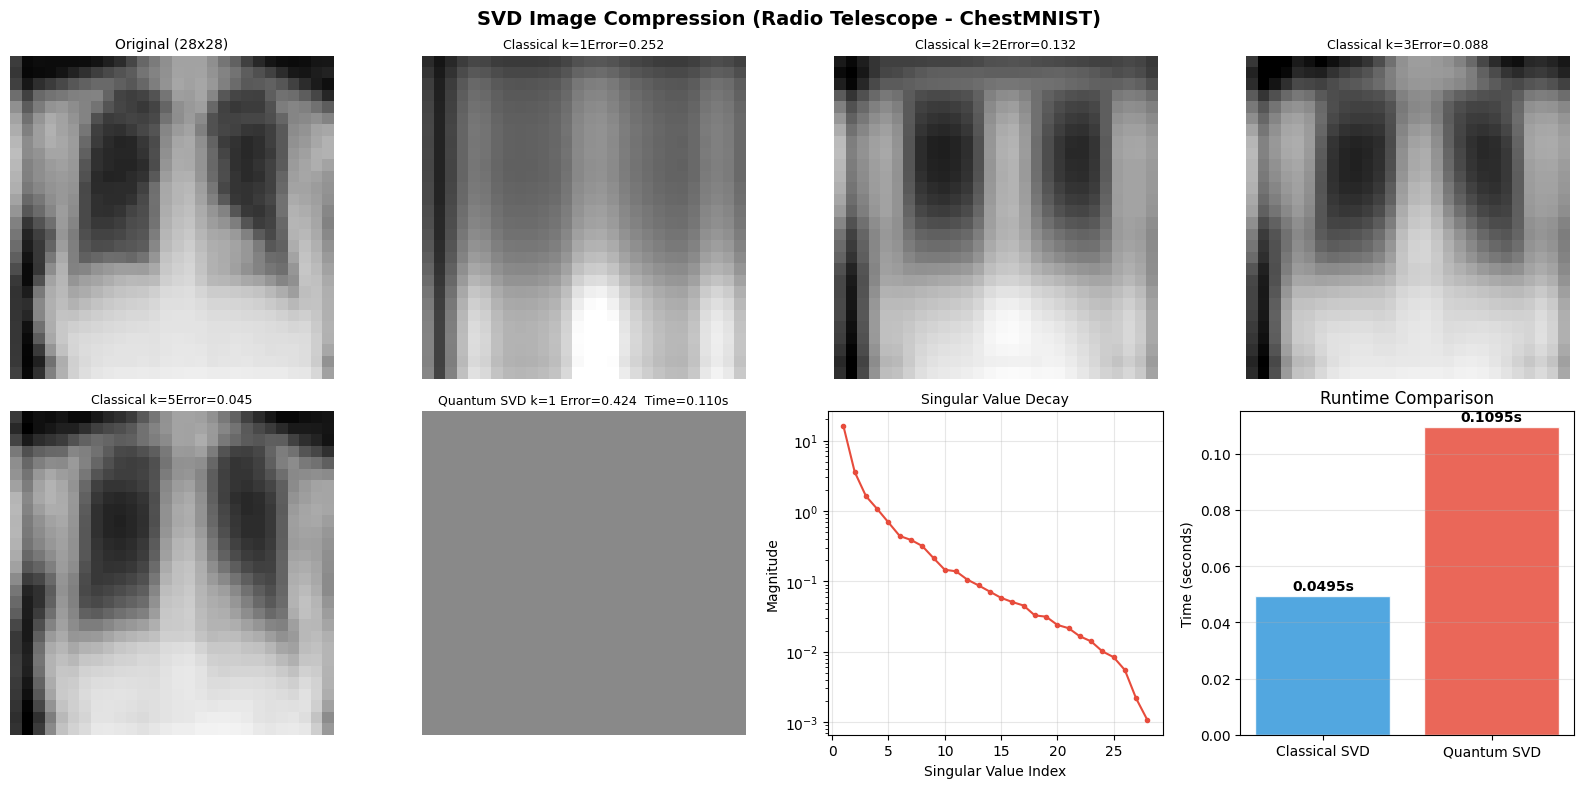

Saved: results/algo6_image_compression_comparison.png


In [44]:
# Visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("SVD Image Compression (Radio Telescope - ChestMNIST)", fontsize=14, fontweight="bold")

# Original
axes[0,0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0,0].set_title(f"Original ({n}x{m})", fontsize=10)
axes[0,0].axis("off")

# Classical k=1,2,3,5
for ax, k in zip(axes.flat[1:5], k_list[:4]):
    img_k = U[:,:k] @ np.diag(s_sv[:k]) @ Vt[:k,:]
    img_k = np.clip(img_k, 0, 1)
    err_k = np.linalg.norm(img - img_k, "fro") / np.linalg.norm(img, "fro")
    ax.imshow(img_k, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Classical k={k}Error={err_k:.3f}", fontsize=9)
    ax.axis("off")

# Quantum rank-1
axes[1,1].imshow(img_rank1_q, cmap="gray", vmin=0, vmax=1)
axes[1,1].set_title(f"Quantum SVD k=1 Error={err_q:.3f}  Time={time_quantum:.3f}s", fontsize=9)
axes[1,1].axis("off")

# Singular value decay
axes[1,2].plot(range(1, len(s_sv)+1), s_sv, "o-", color="#E74C3C", markersize=3)
axes[1,2].set_xlabel("Singular Value Index")
axes[1,2].set_ylabel("Magnitude")
axes[1,2].set_title("Singular Value Decay", fontsize=10)
axes[1,2].set_yscale("log")
axes[1,2].grid(True, alpha=0.3)

# Time comparison
methods_t  = ["Classical SVD", "Quantum SVD"]
times_t    = [time_manual, time_quantum]
bar_colors = ["#3498DB", "#E74C3C"]
bars = axes[1,3].bar(methods_t, times_t, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, t in zip(bars, times_t):
    axes[1,3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                   f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1,3].set_ylabel("Time (seconds)")
axes[1,3].set_title("Runtime Comparison")
axes[1,3].grid(True, axis="y", alpha=0.3)

# Hide unused
axes[1,0].axis("off")

plt.tight_layout()
plt.savefig("results/algo6_image_compression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/algo6_image_compression_comparison.png")